In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sb

In [298]:
# originally tested; works
# year = 2026
# month = "03"
# day = "31"
# daymark example
year = 2025
month = "01"
day = "19"

market = 'rt'  #'rt' or 'da'
dataset = {'rt':'realtime',
          'da':'dayahead'}

url = f"https://www.iso-ne.com/static-transform/csv/histRpts/{market}-energy-offer/hb{dataset[market]}energyoffer_{year}{month}{day}.csv"

# okay the pattern is hbdayaheadenergyoffer_{year}{month}{day}

df = pd.read_csv(url, skiprows=4, skipfooter=1)[1:]

C:\Users\SDotson\AppData\Local\Temp\ipykernel_13220\977296874.py:18: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(url, skiprows=4, skipfooter=1)[1:]


In [299]:
if False:
    df.to_csv(f'{year}-{month}-{day}_isone_{market}_offer_data.csv', index=False)

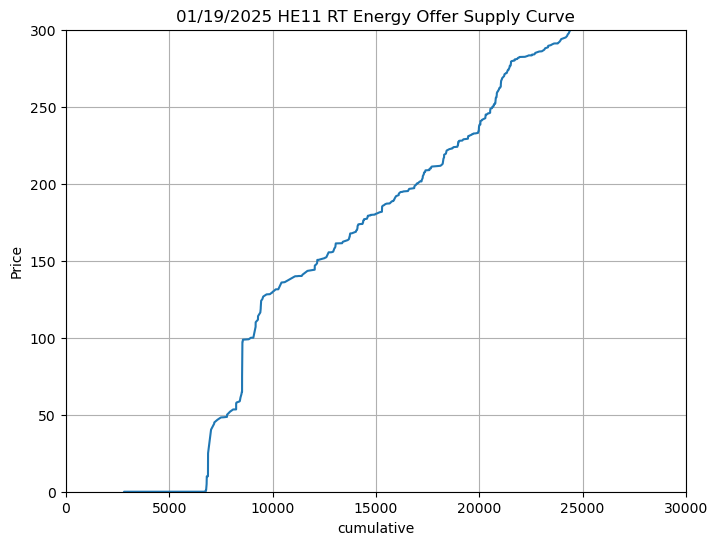

In [301]:
df = df[df['Unit Status'] != "UNAVAILABLE"]
# df = df[df['Unit Status'] == "ECONOMIC"]
to_date = lambda t: dt.datetime.strptime(t,'%m/%d/%Y %H')
hour = 11

id_vars = ['datetime',
           'Masked Lead Participant ID',
           'Masked Asset ID',
           'Unit Status']

df['datetime'] = pd.to_datetime((df['Day']+ ' ' + (df['Trading Interval'].astype(int) - 1).astype('str')).apply(to_date))
df2 = df.drop(columns=['H','Day','Trading Interval'])

seg_power = [f"Segment {n} MW" for n in range(1,11)]
seg_price = [f"Segment {n} Price" for n in range(1,11)]

m = df2.melt(id_vars=id_vars, 
        value_vars=seg_power+seg_price)

m[['segment','measure']] = m['variable'].str.extract('Segment (\d+) (Price|MW)')
m['value'] = m['value'].astype('float')
m = m.pivot_table(index=id_vars+['segment'], columns=['measure'], values='value').reset_index().set_index('datetime')
m = m[(m['MW'] > 0) & (m['MW']<9999)]

test2 = m.loc[m.index.hour==hour].sort_values(by='Price', ascending=True)
test2['cumulative'] = test2['MW'].cumsum()


fig, ax = plt.subplots(figsize=(8,6))
# sb.scatterplot(ax=ax,data=test2, x='cumulative',y='Price', 
#                hue='Unit Status',
#                 legend=True)
sb.lineplot(ax=ax,data=test2, x='cumulative',y='Price', 
                legend=True)
ax.set_title(f"{month}/{day}/{year} HE{hour} {market.upper()} Energy Offer Supply Curve")
ax.set_ylim(0, 300)
ax.set_xlim(0,30e3)
ax.grid(which='major')

In [306]:
test2[test2['cumulative'] < 6.8e3]

measure,Masked Lead Participant ID,Masked Asset ID,Unit Status,segment,MW,Price,cumulative
datetime,,,,,,,
2025-01-19 11:00:00,989046,42750,MUST_RUN,1,15.0,-150.0,15.0
2025-01-19 11:00:00,985313,90307,ECONOMIC,1,17.0,-150.0,32.0
2025-01-19 11:00:00,974156,13275,MUST_RUN,1,20.0,-150.0,52.0
2025-01-19 11:00:00,974156,13275,MUST_RUN,2,15.0,-150.0,67.0
2025-01-19 11:00:00,184983,57591,MUST_RUN,2,0.6,-150.0,67.6
...,...,...,...,...,...,...,...
2025-01-19 11:00:00,463516,17945,MUST_RUN,1,7.0,0.1,6761.5
2025-01-19 11:00:00,165161,97200,ECONOMIC,1,7.0,1.0,6768.5
2025-01-19 11:00:00,165161,88568,ECONOMIC,1,6.0,1.0,6774.5
